<a href="https://colab.research.google.com/github/cocyten27/MODULE_6/blob/main/M6_L14_fft_spectrograms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TAE-IA · Module 6 · L14 — The Frequency World: FFT and Spectrograms

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L14 |
| **Track** | B — Audio |
| **Runtime** | CPU is sufficient — no GPU required |
| **Drive quota** | No large model downloads — no cleanup needed |

## Learning objectives

By the end of this notebook you will be able to:
1. Compute and plot the FFT power spectrum of a signal and identify peaks by frequency
2. Explain the difference between FFT (global) and STFT (windowed) representations
3. Generate STFT spectrograms with `librosa.stft()` and `librosa.display.specshow()`
4. Quantify how `n_fft` and `hop_length` control frequency vs. time resolution
5. Read a spectrogram and identify phonetic and musical events by their spectral shape

---

## Cell 0 — Setup

In [ ]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'
os.makedirs(MODEL_CACHE, exist_ok=True)

os.environ['HF_HOME']            = MODEL_CACHE
os.environ['TORCH_HOME']         = MODEL_CACHE
os.environ['TRANSFORMERS_CACHE'] = os.path.join(MODEL_CACHE, 'hub')

SEED = 42
random.seed(SEED); np.random.seed(SEED)

print('Setup complete. CPU runtime is sufficient for L14.')

Mounted at /content/drive
Setup complete. CPU runtime is sufficient for L14.


## Cell 1 — Install and import

In [ ]:
!pip install librosa soundfile -q

import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import IPython.display as ipd

print(f'librosa {librosa.__version__}')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

librosa 0.11.0


## Cell 2 — Regenerate L13 audio signals

We regenerate the same three synthetic signals from L13 so this notebook is self-contained.

In [ ]:
SR  = 22050
DUR = 3.0
N   = int(SR * DUR)
t   = np.linspace(0, DUR, N, endpoint=False)

# Voice-like: harmonic series + syllable envelope + silence gaps
f0 = 150.0
y_voice = sum((1.0 / k) * np.sin(2 * np.pi * f0 * k * t) for k in range(1, 8))
env = 0.5 + 0.5 * np.sin(2 * np.pi * 5 * t)
gap = np.ones(N)
gap[int(0.3*SR):int(0.5*SR)] = 0.0
gap[int(1.8*SR):int(2.0*SR)] = 0.0
y_voice = (y_voice * env * gap).astype(np.float32)
y_voice /= np.abs(y_voice).max() + 1e-8

# Music-like: A-major chord with tremolo
y_music = sum(np.sin(2 * np.pi * f * t) for f in [440.0, 554.37, 659.25])
y_music = (y_music * (1.0 + 0.3 * np.sin(2 * np.pi * 6 * t))).astype(np.float32)
y_music /= np.abs(y_music).max() + 1e-8

# Ambient-like: band-limited pink noise
rng   = np.random.default_rng(SEED)
white = rng.normal(0, 1, N).astype(np.float32)
fft_w = np.fft.rfft(white)
freqs = np.fft.rfftfreq(N, d=1.0/SR)
band  = ((freqs >= 200) & (freqs <= 4000)).astype(float)
with np.errstate(divide='ignore', invalid='ignore'):
    pink = np.where(freqs > 200, 200.0 / freqs, 1.0)
y_ambient = np.fft.irfft(fft_w * band * pink, n=N).astype(np.float32)
y_ambient /= np.abs(y_ambient).max() + 1e-8

AUDIO = {'voice': (y_voice, SR), 'music': (y_music, SR), 'ambient': (y_ambient, SR)}
COLOURS = {'voice': '#2C75FF', 'music': '#27ae60', 'ambient': '#8e44ad'}

print('Audio regenerated.')
for name, (y, sr) in AUDIO.items():
    print(f'  {name}: {len(y)} samples, {len(y)/sr:.1f}s')

Audio regenerated.
  voice: 66150 samples, 3.0s
  music: 66150 samples, 3.0s
  ambient: 66150 samples, 3.0s


---
## Section 2.1 — FFT Power Spectrum

The FFT takes the **entire signal** and produces a list of frequency components.

**Key concepts:**
- `np.fft.rfft(y)` — real FFT: returns `N//2 + 1` complex values (positive frequencies only)
- Magnitude: `np.abs(fft_result)` — how much of each frequency is present
- Frequency axis: `np.fft.rfftfreq(N, d=1/sr)` — maps each bin index to Hz
- Frequency resolution: `sr / N` Hz per bin — finer with more samples
- **Always apply a window function** (e.g., Hanning) before FFT to reduce *spectral leakage* — the smearing of energy from one frequency bin into adjacent bins.

Signal: 1s at 22050 Hz → 22050 samples
FFT output: 11026 bins, frequency resolution = 1.00 Hz/bin
Peak bin index: 440  → frequency: 440.0 Hz


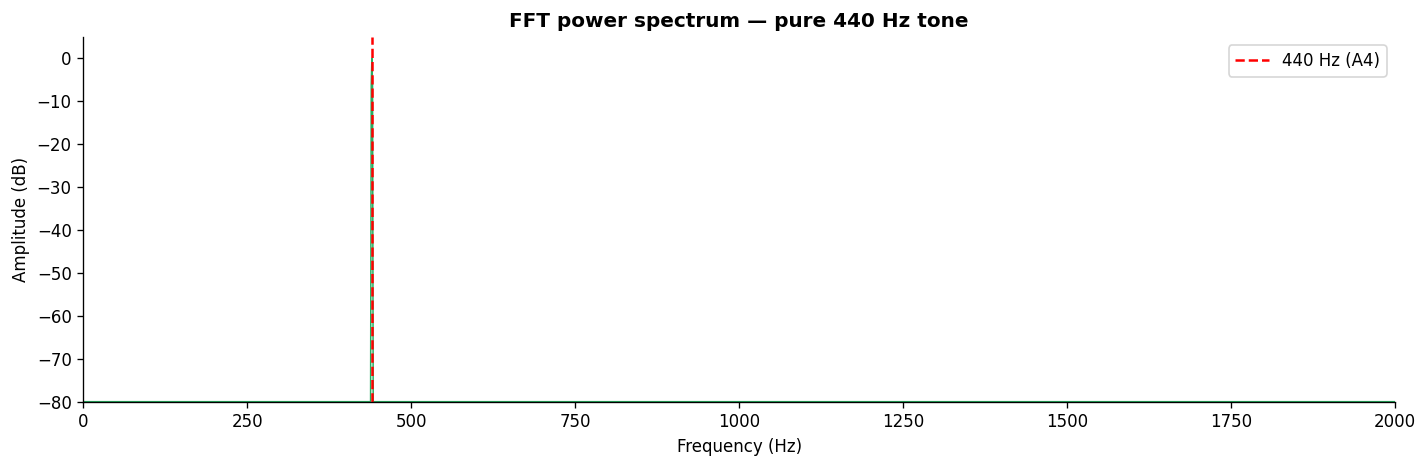

In [ ]:
# First: intuition with a pure 440 Hz tone
t_1s  = np.linspace(0, 1.0, SR, endpoint=False)
y_440 = np.sin(2 * np.pi * 440 * t_1s).astype(np.float32)

window = np.hanning(len(y_440))
fft_   = np.fft.rfft(y_440 * window)
mag    = np.abs(fft_)
freq   = np.fft.rfftfreq(len(y_440), d=1.0/SR)
mag_db = librosa.amplitude_to_db(mag, ref=mag.max())

freq_res = SR / len(y_440)
print(f'Signal: 1s at {SR} Hz → {len(y_440)} samples')
print(f'FFT output: {len(mag)} bins, frequency resolution = {freq_res:.2f} Hz/bin')
print(f'Peak bin index: {np.argmax(mag)}  → frequency: {freq[np.argmax(mag)]:.1f} Hz')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(freq, mag_db, color='#27ae60', linewidth=0.9)
ax.axvline(440, color='red', linewidth=1.5, linestyle='--', label='440 Hz (A4)')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Amplitude (dB)')
ax.set_title('FFT power spectrum — pure 440 Hz tone', fontweight='bold')
ax.set_xlim(0, 2000)
ax.set_ylim(-80, 5)
ax.legend()
plt.tight_layout()
plt.show()

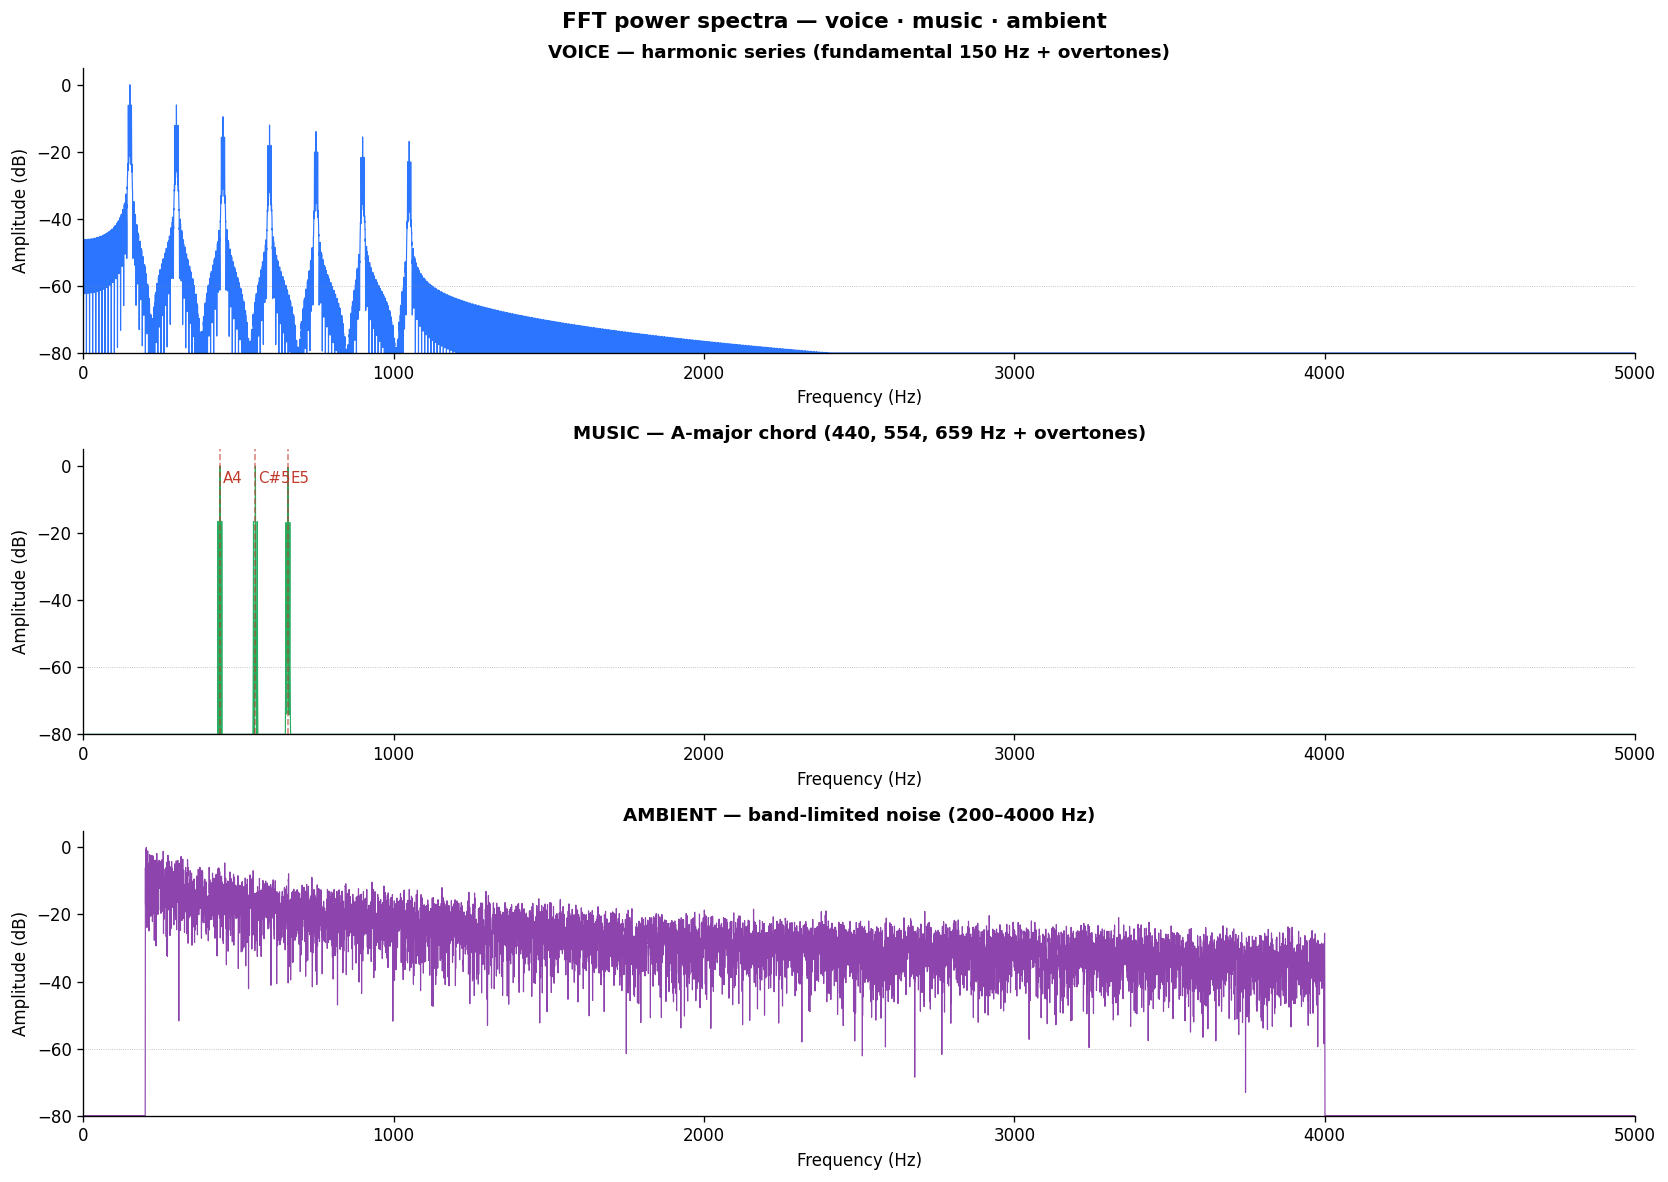

In [ ]:
def plot_fft(y, sr, title, ax, color='#27ae60', xlim=5000):
    """Plot FFT power spectrum with Hanning window."""
    N      = len(y)
    window = np.hanning(N)
    fft_   = np.fft.rfft(y * window)
    mag    = np.abs(fft_)
    freq   = np.fft.rfftfreq(N, d=1.0/sr)
    mag_db = librosa.amplitude_to_db(mag, ref=mag.max())

    ax.plot(freq, mag_db, color=color, linewidth=0.7)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Amplitude (dB)')
    ax.set_xlim(0, xlim)
    ax.set_ylim(-80, 5)
    ax.axhline(-60, color='gray', linewidth=0.5, linestyle=':', alpha=0.6)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

plot_fft(y_voice,   SR, 'VOICE — harmonic series (fundamental 150 Hz + overtones)', axes[0], COLOURS['voice'])
plot_fft(y_music,   SR, 'MUSIC — A-major chord (440, 554, 659 Hz + overtones)',     axes[1], COLOURS['music'])
plot_fft(y_ambient, SR, 'AMBIENT — band-limited noise (200–4000 Hz)',                axes[2], COLOURS['ambient'])

# Annotate chord peaks
for f, label in [(440, 'A4'), (554, 'C#5'), (659, 'E5')]:
    axes[1].axvline(f, color='#c0392b', linewidth=1.0, linestyle='--', alpha=0.6)
    axes[1].text(f + 10, -5, label, color='#c0392b', fontsize=9)

plt.suptitle('FFT power spectra — voice · music · ambient', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 2.2 — STFT Spectrograms

The STFT applies the FFT to **short overlapping windows** of the signal, producing a 2D matrix:
- Rows = frequency bins (0 to Nyquist)
- Columns = time frames
- Values = complex STFT coefficients; we take the magnitude and convert to dB

**Always convert to dB before plotting** — the raw linear magnitude compresses 99% of the dynamic range into a tiny bright band at the top.

In [ ]:
# Compute STFT for all three signals with default parameters
N_FFT   = 2048
HOP_LEN = 512

spectrograms = {}
for name, (y, sr) in AUDIO.items():
    D = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LEN, window='hann')
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    spectrograms[name] = S_db

    freq_res = sr / N_FFT
    time_res = HOP_LEN / sr * 1000
    n_frames = D.shape[1]
    print(f'{name}: shape={D.shape}  freq_res={freq_res:.1f} Hz/bin  '
          f'time_res={time_res:.1f} ms/frame  n_frames={n_frames}')

voice: shape=(1025, 130)  freq_res=10.8 Hz/bin  time_res=23.2 ms/frame  n_frames=130
music: shape=(1025, 130)  freq_res=10.8 Hz/bin  time_res=23.2 ms/frame  n_frames=130
ambient: shape=(1025, 130)  freq_res=10.8 Hz/bin  time_res=23.2 ms/frame  n_frames=130


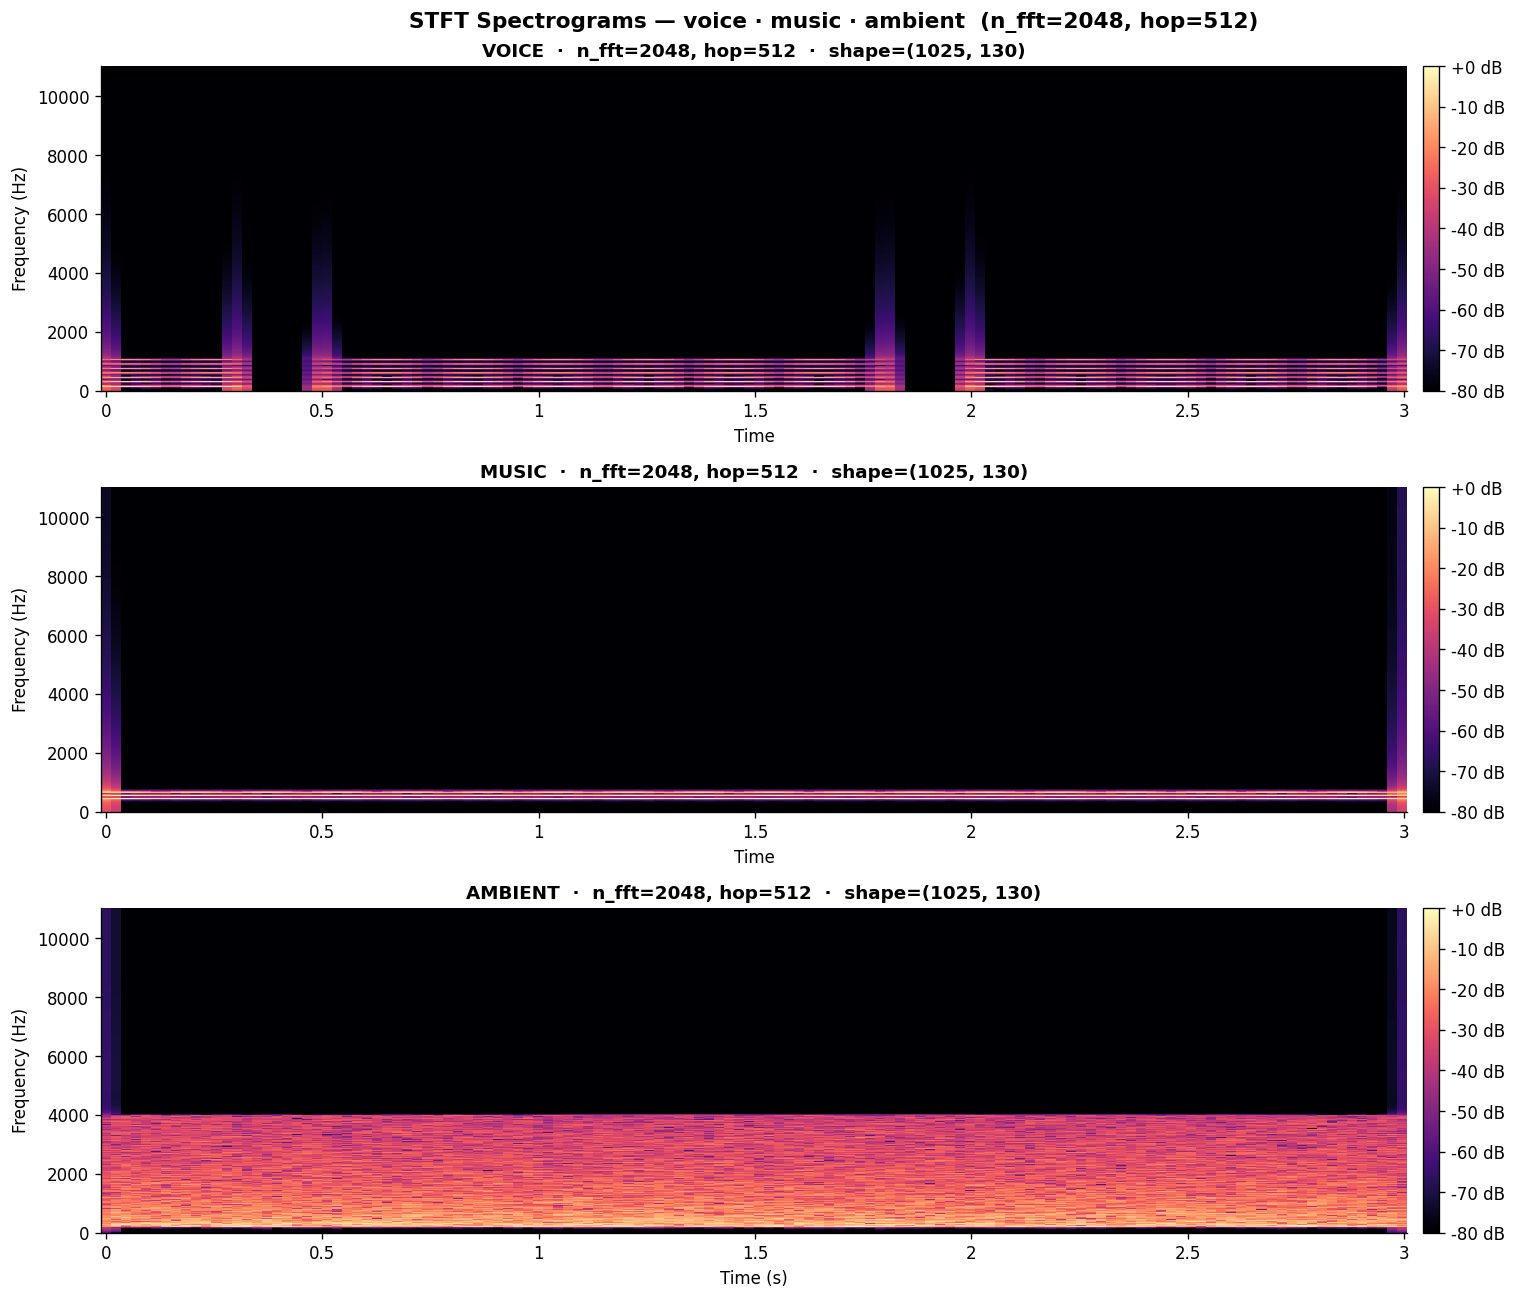

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

for ax, (name, (y, sr)) in zip(axes, AUDIO.items()):
    S_db = spectrograms[name]
    img  = librosa.display.specshow(
        S_db, sr=sr, hop_length=HOP_LEN,
        x_axis='time', y_axis='hz',
        ax=ax, cmap='magma'
    )
    ax.set_title(f'{name.upper()}  ·  n_fft={N_FFT}, hop={HOP_LEN}  '
                 f'·  shape={S_db.shape}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency (Hz)')
    plt.colorbar(img, ax=ax, format='%+2.0f dB', pad=0.01)

axes[-1].set_xlabel('Time (s)')
plt.suptitle('STFT Spectrograms — voice · music · ambient  (n_fft=2048, hop=512)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### What to look for in the spectrograms:

| Signal | Characteristic pattern | Reason |
|---|---|---|
| **Voice** | Horizontal bright bands (formants) with vertical dark gaps | Formants = vowel resonances; gaps = silence between syllables |
| **Music** | Horizontal stripes at fixed frequencies with harmonics above | Chord frequencies + their overtone series; tremolo = amplitude modulation |
| **Ambient** | Uniform texture — energy spread across frequencies and time | Noise has no dominant frequency or time structure |

---
## Section 2.3 — `n_fft` Sweep: Observing the Resolution Trade-off

The same voice clip rendered with three values of `n_fft`. The `hop_length` is fixed so time resolution only changes through the window length effect.

**What to expect:**
- `n_fft=256`: blurry frequency axis (86 Hz/bin), sharp time axis — good for transients
- `n_fft=1024`: balanced — the general-purpose default
- `n_fft=4096`: sharp frequency axis (5.4 Hz/bin), smeared time axis — good for pitch

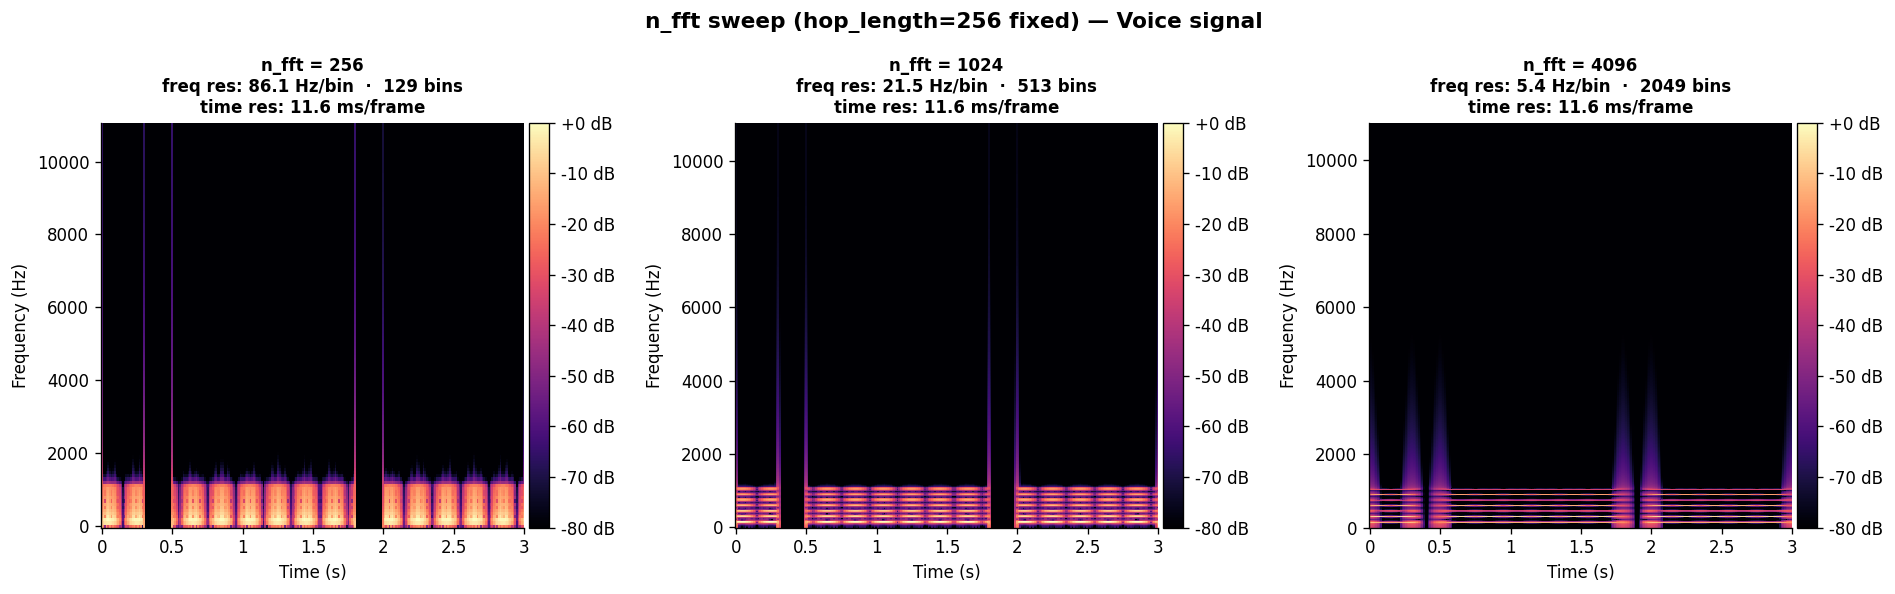

In [ ]:
n_fft_values = [256, 1024, 4096]
HOP_FIXED    = 256
y_v, sr_v    = AUDIO['voice']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, n_fft in zip(axes, n_fft_values):
    D    = librosa.stft(y_v, n_fft=n_fft, hop_length=HOP_FIXED, window='hann')
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

    freq_res = sr_v / n_fft
    time_res = HOP_FIXED / sr_v * 1000
    n_bins   = D.shape[0]

    img = librosa.display.specshow(
        S_db, sr=sr_v, hop_length=HOP_FIXED,
        x_axis='time', y_axis='hz',
        ax=ax, cmap='magma'
    )
    ax.set_title(
        f'n_fft = {n_fft}\n'
        f'freq res: {freq_res:.1f} Hz/bin  ·  {n_bins} bins\n'
        f'time res: {time_res:.1f} ms/frame',
        fontsize=10, fontweight='bold'
    )
    ax.set_ylabel('Frequency (Hz)')
    ax.set_xlabel('Time (s)')
    plt.colorbar(img, ax=ax, format='%+2.0f dB', pad=0.01)

plt.suptitle(f'n_fft sweep (hop_length={HOP_FIXED} fixed) — Voice signal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Resolution table for all common n_fft values at 22050 Hz
print(f'{"n_fft":>8}  {"freq res (Hz/bin)":>20}  {"#bins":>7}  {"window len (ms)":>18}')
print('-' * 62)
for n in [128, 256, 512, 1024, 2048, 4096]:
    freq_res = SR / n
    win_ms   = n / SR * 1000
    n_bins   = n // 2 + 1
    marker   = ' ← Whisper default' if n == 400 else (
               ' ← music default'   if n == 2048 else '')
    print(f'{n:>8}  {freq_res:>20.2f}  {n_bins:>7}  {win_ms:>18.1f}{marker}')

   n_fft     freq res (Hz/bin)    #bins     window len (ms)
--------------------------------------------------------------
     128                172.27       65                 5.8
     256                 86.13      129                11.6
     512                 43.07      257                23.2
    1024                 21.53      513                46.4
    2048                 10.77     1025                92.9 ← music default
    4096                  5.38     2049               185.8


---
## Section 2.4 — `hop_length` Sweep

Now fix `n_fft` and vary `hop_length`. This changes **how many time frames** appear in the spectrogram without changing frequency resolution.

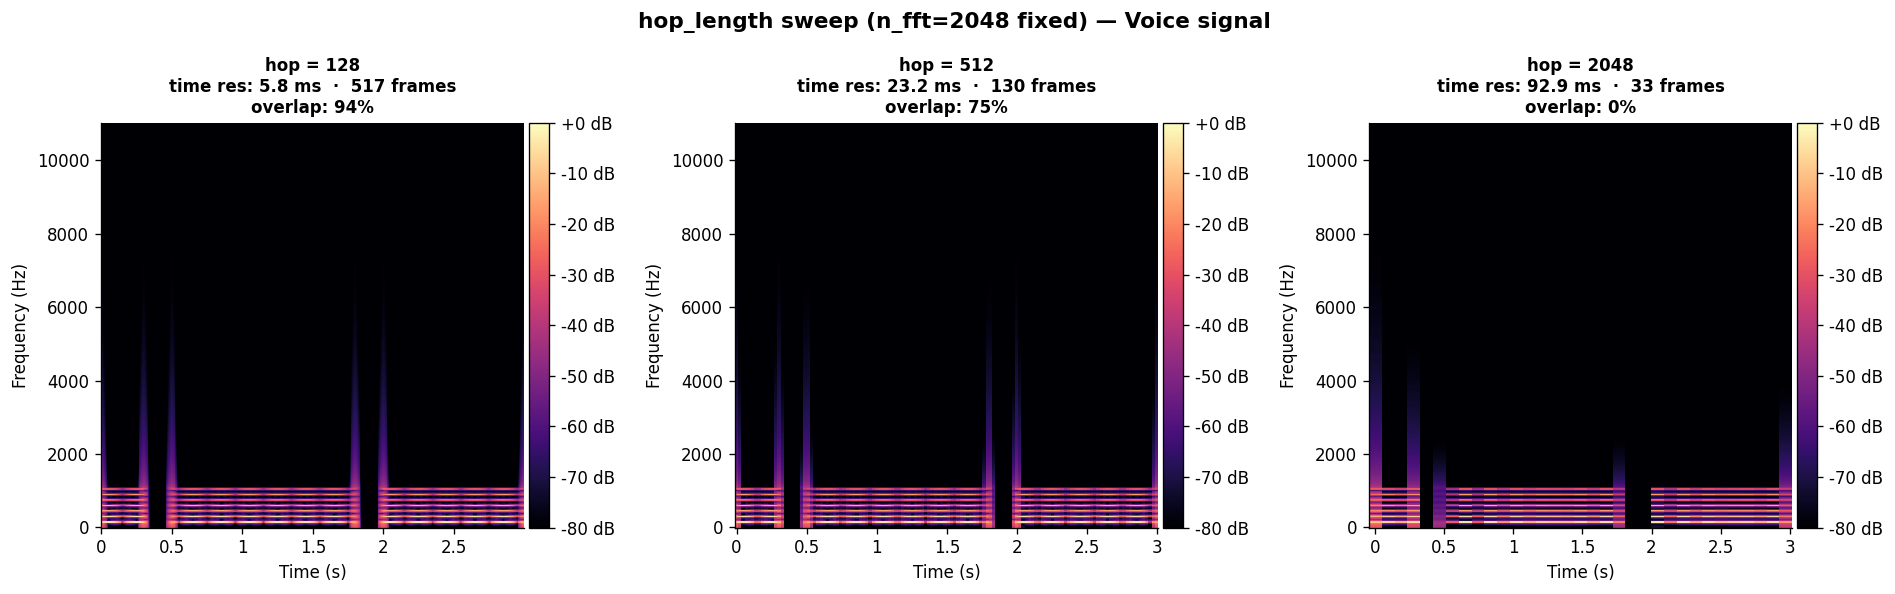

In [ ]:
hop_values = [128, 512, 2048]
N_FFT_FIXED = 2048

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, hop in zip(axes, hop_values):
    D    = librosa.stft(y_v, n_fft=N_FFT_FIXED, hop_length=hop, window='hann')
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

    time_res = hop / sr_v * 1000
    n_frames = D.shape[1]
    overlap  = (1 - hop / N_FFT_FIXED) * 100

    img = librosa.display.specshow(
        S_db, sr=sr_v, hop_length=hop,
        x_axis='time', y_axis='hz',
        ax=ax, cmap='magma'
    )
    ax.set_title(
        f'hop = {hop}\n'
        f'time res: {time_res:.1f} ms  ·  {n_frames} frames\n'
        f'overlap: {overlap:.0f}%',
        fontsize=10, fontweight='bold'
    )
    ax.set_ylabel('Frequency (Hz)')
    ax.set_xlabel('Time (s)')
    plt.colorbar(img, ax=ax, format='%+2.0f dB', pad=0.01)

plt.suptitle(f'hop_length sweep (n_fft={N_FFT_FIXED} fixed) — Voice signal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 2.5 — Waveform + Spectrogram Side-by-Side

Aligning the waveform and spectrogram in time makes it easier to see which waveform events correspond to which spectral patterns.

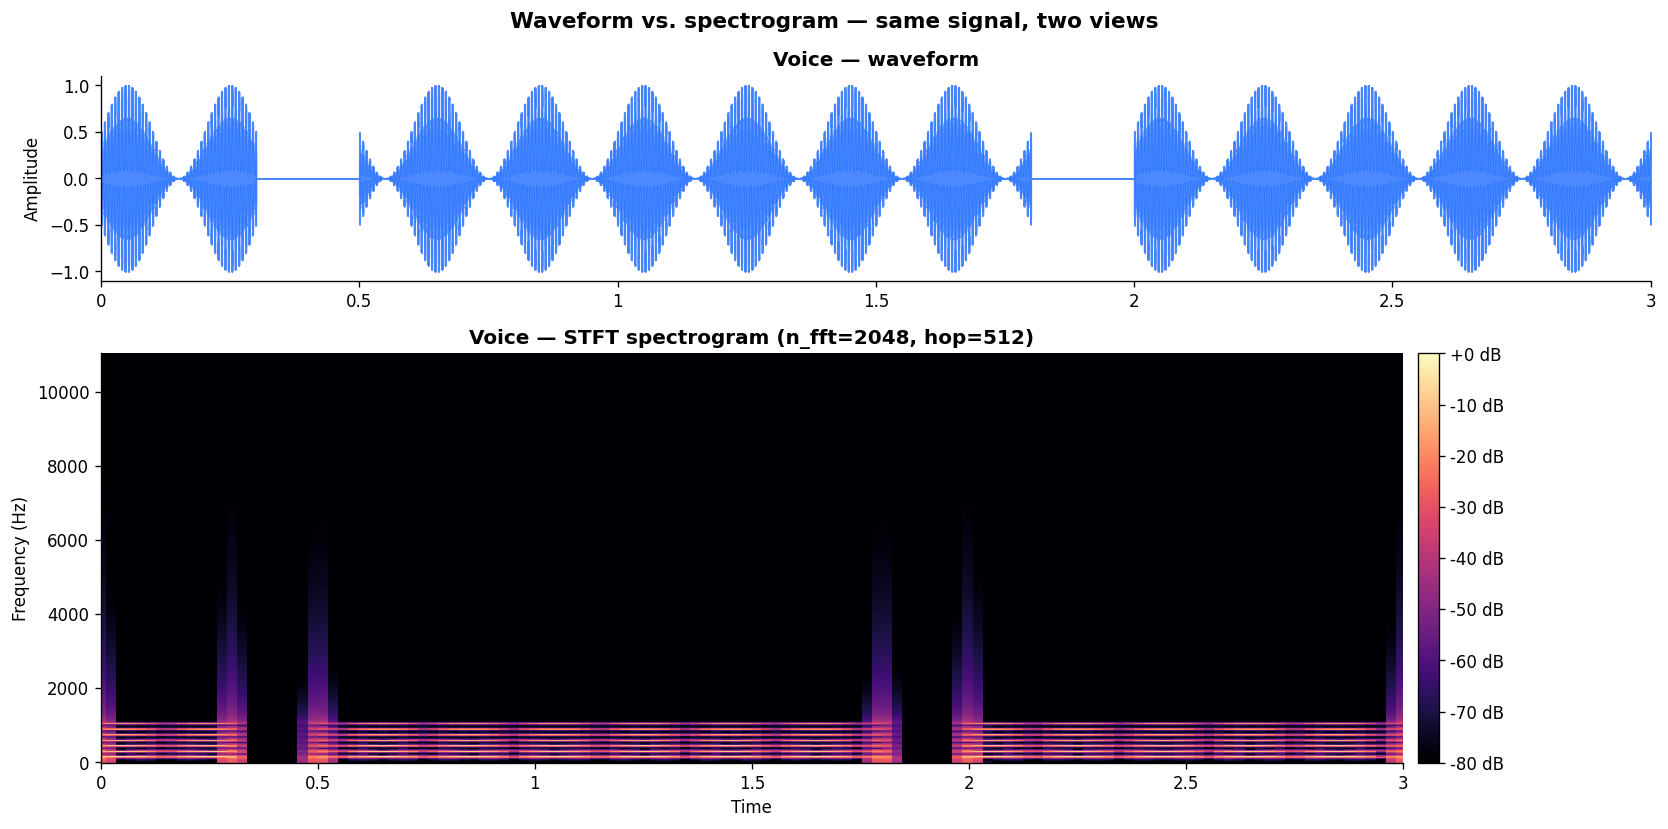


Observe: the silence gaps in the waveform (flat near zero) appear as dark vertical bands in the spectrogram.


In [ ]:
fig, (ax_wave, ax_spec) = plt.subplots(2, 1, figsize=(14, 7),
                                         gridspec_kw={'height_ratios': [1, 2]})

# Waveform
librosa.display.waveshow(y_v, sr=SR, ax=ax_wave, color=COLOURS['voice'], alpha=0.85)
ax_wave.set_title('Voice — waveform', fontweight='bold')
ax_wave.set_xlabel('')
ax_wave.set_ylabel('Amplitude')

# Spectrogram
D    = librosa.stft(y_v, n_fft=2048, hop_length=512)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
img  = librosa.display.specshow(S_db, sr=SR, hop_length=512,
                                  x_axis='time', y_axis='hz',
                                  ax=ax_spec, cmap='magma')
ax_spec.set_title('Voice — STFT spectrogram (n_fft=2048, hop=512)', fontweight='bold')
ax_spec.set_ylabel('Frequency (Hz)')
plt.colorbar(img, ax=ax_spec, format='%+2.0f dB', pad=0.01)

# Align x-axis
ax_wave.set_xlim(0, DUR)
ax_spec.set_xlim(0, DUR)

plt.suptitle('Waveform vs. spectrogram — same signal, two views', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nObserve: the silence gaps in the waveform (flat near zero) appear as dark vertical'
      ' bands in the spectrogram.')

---
## Exercise 1 — Multi-tone identification

Generate a signal that contains **two different tones in sequence**: 330 Hz for the first 1.5 seconds, then 660 Hz for the last 1.5 seconds.

1. Compute the global FFT. Can you distinguish the two tones?
2. Compute the STFT spectrogram. Can you distinguish the two tones?
3. Explain in a markdown cell why the two representations give different results for this signal.

This exercise directly motivates the STFT: the FFT cannot answer "when did the pitch change?"

In [ ]:
# Two-tone signal: 330 Hz → 660 Hz
t_half = np.linspace(0, 1.5, int(SR * 1.5), endpoint=False)
y_low  = np.sin(2 * np.pi * 330 * t_half).astype(np.float32)
y_high = np.sin(2 * np.pi * 660 * t_half).astype(np.float32)
y_two_tones = np.concatenate([y_low, y_high])

# Play it
ipd.display(ipd.Audio(y_two_tones, rate=SR))

# TODO: compute and plot both FFT and STFT for y_two_tones
# Then answer Q3 in a markdown cell below

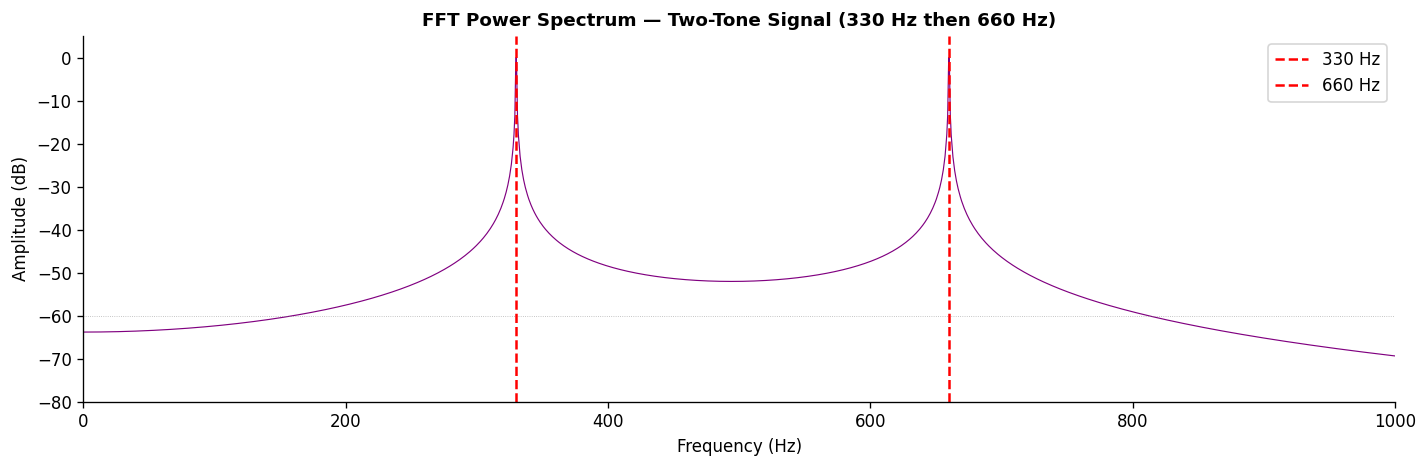

In [ ]:
import matplotlib.pyplot as plt

# Plotting FFT for y_two_tones
fig, ax = plt.subplots(figsize=(12, 4))
plot_fft(y_two_tones, SR, 'FFT Power Spectrum — Two-Tone Signal (330 Hz then 660 Hz)', ax, color='purple', xlim=1000)

# Annotate the expected peaks
ax.axvline(330, color='red', linewidth=1.5, linestyle='--', label='330 Hz')
ax.axvline(660, color='red', linewidth=1.5, linestyle='--', label='660 Hz')
ax.legend()
plt.tight_layout()
plt.show()

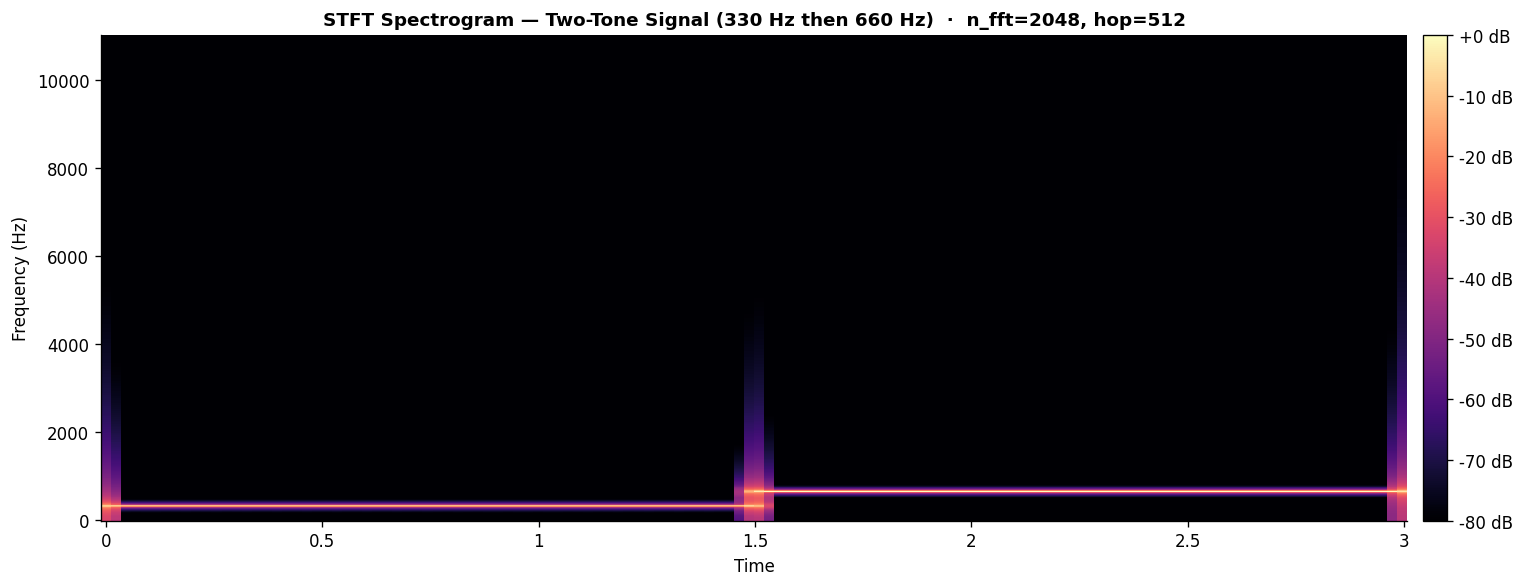

In [ ]:
# Plotting STFT for y_two_tones

# Use the default N_FFT and HOP_LEN from earlier sections
N_FFT_EX1 = 2048
HOP_LEN_EX1 = 512

D_two_tones = librosa.stft(y_two_tones, n_fft=N_FFT_EX1, hop_length=HOP_LEN_EX1, window='hann')
S_db_two_tones = librosa.amplitude_to_db(np.abs(D_two_tones), ref=np.max)

fig, ax = plt.subplots(figsize=(14, 5))
img = librosa.display.specshow(
    S_db_two_tones, sr=SR, hop_length=HOP_LEN_EX1,
    x_axis='time', y_axis='hz',
    ax=ax, cmap='magma'
)
ax.set_title(
    f'STFT Spectrogram — Two-Tone Signal (330 Hz then 660 Hz)  ·  n_fft={N_FFT_EX1}, hop={HOP_LEN_EX1}',
    fontsize=11, fontweight='bold'
)
ax.set_ylabel('Frequency (Hz)')
plt.colorbar(img, ax=ax, format='%+2.0f dB', pad=0.01)
plt.tight_layout()
plt.show()

**Exercise 1 — Answer:**

[YOUR ANSWER — explain why FFT cannot separate the two tones in time, but STFT can]

## Exercise 1 — Answer:

El FFT (Transformada Rápida de Fourier) proporciona una vista global de todas las frecuencias presentes en una señal a lo largo de su duración total. Para la señal `y_two_tones`, que contiene 330 Hz durante la primera mitad y 660 Hz durante la segunda, el FFT mostrará picos prominentes en ambas frecuencias (330 Hz y 660 Hz). Sin embargo, el FFT no proporciona ninguna información sobre *cuándo* estuvieron presentes estas frecuencias. Trata toda la señal como una única entidad, por lo que no puede distinguir el cambio temporal de tono.

Por el contrario, el STFT (Transformada de Fourier de Corto Tiempo) aplica el FFT a pequeñas ventanas superpuestas de la señal. Esto permite analizar cómo las frecuencias cambian con el tiempo. El espectrograma resultante muestra claramente el cambio de frecuencia. Veremos una banda brillante alrededor de 330 Hz durante la primera mitad de la señal, que luego cambia a una banda brillante alrededor de 660 Hz en la segunda mitad, revelando la evolución temporal del tono. Por lo tanto, el STFT es la herramienta adecuada para analizar señales no estacionarias donde las características de frecuencia cambian a lo largo del tiempo.

---
## Exercise 2 — Optimal parameters for a speech task

Whisper uses `n_fft=400` and `hop_length=160` at 16000 Hz.

1. Compute the frequency resolution and time resolution for Whisper's parameters
2. Resampled `y_voice` to 16000 Hz and plot its spectrogram using Whisper's exact parameters
3. In a markdown cell: explain why Whisper chose a relatively small `n_fft=400` (25 ms window) instead of the music default of 2048 (~93 ms). What acoustic property of speech makes 25 ms appropriate?

Whisper STFT parameters:
  n_fft=400  hop=160  sr=16000
  Frequency resolution : 40.0 Hz/bin
  Time resolution      : 10.0 ms/frame
  Window duration      : 25.0 ms


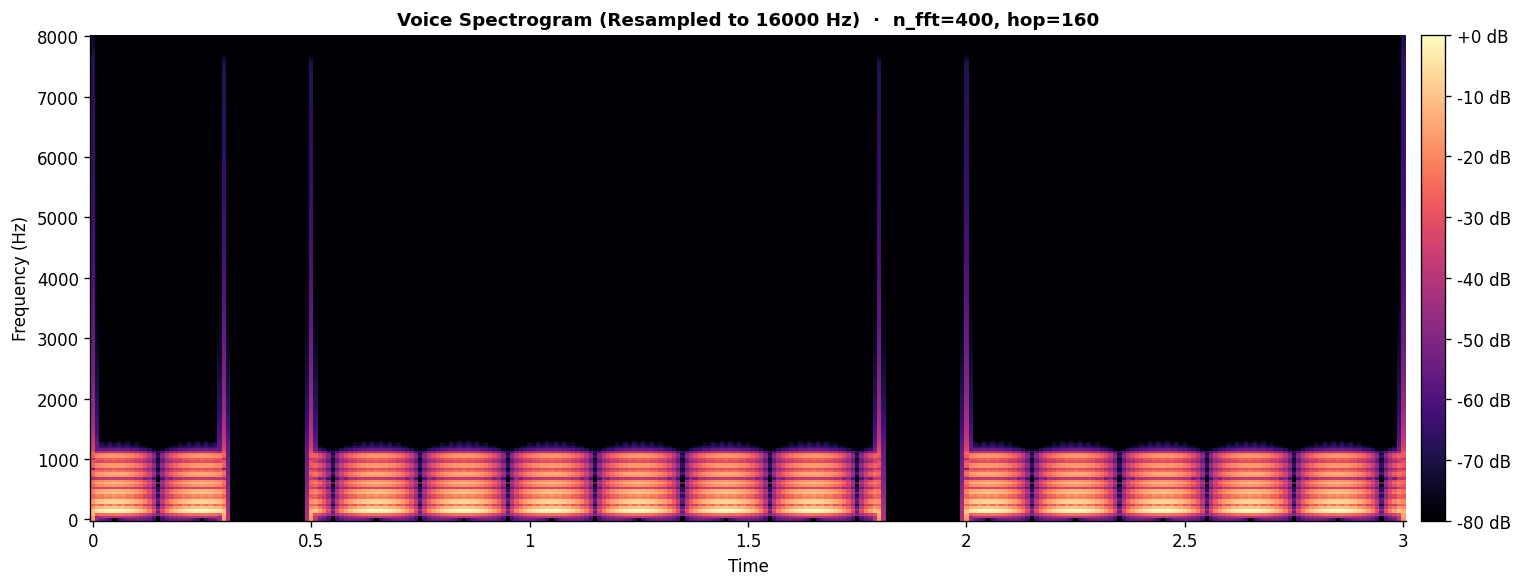

In [ ]:
# Whisper parameters
N_FFT_WHISPER  = 400
HOP_WHISPER    = 160
SR_WHISPER     = 16000

freq_res = SR_WHISPER / N_FFT_WHISPER
time_res = HOP_WHISPER / SR_WHISPER * 1000
print(f'Whisper STFT parameters:')
print(f'  n_fft={N_FFT_WHISPER}  hop={HOP_WHISPER}  sr={SR_WHISPER}')
print(f'  Frequency resolution : {freq_res:.1f} Hz/bin')
print(f'  Time resolution      : {time_res:.1f} ms/frame')
print(f'  Window duration      : {N_FFT_WHISPER/SR_WHISPER*1000:.1f} ms')

# Resample y_voice to 16000 Hz
y_voice_16k = librosa.resample(y_voice, orig_sr=SR, target_sr=SR_WHISPER)

# Compute and plot spectrogram with Whisper parameters
D_whisper = librosa.stft(y_voice_16k, n_fft=N_FFT_WHISPER, hop_length=HOP_WHISPER, window='hann')
S_db_whisper = librosa.amplitude_to_db(np.abs(D_whisper), ref=np.max)

fig, ax = plt.subplots(figsize=(14, 5))
img = librosa.display.specshow(
    S_db_whisper, sr=SR_WHISPER, hop_length=HOP_WHISPER,
    x_axis='time', y_axis='hz',
    ax=ax, cmap='magma'
)
ax.set_title(
    f'Voice Spectrogram (Resampled to {SR_WHISPER} Hz)  ·  n_fft={N_FFT_WHISPER}, hop={HOP_WHISPER}',
    fontsize=11, fontweight='bold'
)
ax.set_ylabel('Frequency (Hz)')
plt.colorbar(img, ax=ax, format='%+2.0f dB', pad=0.01)
plt.tight_layout()
plt.show()

## Exercise 2 — Answer:

Whisper elige un `n_fft` relativamente pequeño de 400 (que corresponde a una ventana de 25 ms a 16000 Hz) porque las características fonéticas del habla cambian rápidamente en el tiempo. Un `n_fft` más pequeño proporciona una mejor resolución temporal, lo que es crucial para capturar los rápidos transitorios y las articulaciones de los fonemas del habla, como las consonantes oclusivas y fricativas, que duran entre 5 y 50 ms. Si se utilizara un `n_fft` más grande, como el predeterminado de 2048 para música (~93 ms), se 'emborronarían' estos eventos rápidos en el tiempo, lo que dificultaría la distinción entre diferentes fonemas. Aunque se sacrifica algo de resolución de frecuencia, la resolución temporal es más crítica para la inteligibilidad del habla y el rendimiento del reconocimiento automático.

---
## Part 4 — Critical Analysis

Answer all four questions with real outputs from the cells above.

### Q1 — FFT and ZCR

From your Section 2.1 FFT spectra: which of the three signals has the highest ZCR (recall from L13)? Does the FFT spectrum visually confirm why? Explain the connection between ZCR and spectral flatness in 2–3 sentences.

**[YOUR ANSWER]**

De entre las tres señales, la señal ambiental presenta el valor de ZCR más elevado. El espectro FFT de la señal ambiental confirma visualmente este hecho, ya que muestra una distribución de energía muy amplia y relativamente plana en un extenso rango de frecuencias, característica propia del ruido. Por el contrario, las señales de voz y música exhiben picos marcados y definidos, lo que indica la presencia de componentes tonales intensos.

La relación entre el ZCR y la planitud espectral radica en que las señales con un ZCR elevado tienden a presentar espectros FFT más planos. Esto se debe a que los cambios rápidos y frecuentes en la amplitud de la señal (que generan numerosos cruces por cero) distribuyen la energía de manera más amplia en el dominio de la frecuencia, en lugar de concentrarla en picos armónicos específicos. Por consiguiente, un espectro más plano suele implicar un mayor grado de aleatoriedad o ruido, lo que se correlaciona con un ZCR más alto.

### Q2 — Spectrogram patterns

In your Section 2.2 spectrograms, identify **one feature** that appears in the voice spectrogram but not in the ambient spectrogram. Name:
- The approximate frequency range it occupies (Hz)
- What acoustic event it represents
- Whether you could detect that event from the waveform alone

**[YOUR ANSWER]**

Una característica distintiva que aparece en el espectrograma de voz pero no en el espectrograma ambiental son las **bandas horizontales brillantes (formantes)**, especialmente evidentes en el rango de bajas frecuencias.

- **Rango de frecuencia aproximado:** Estas bandas ocupan principalmente el rango de **0 Hz a aproximadamente 2000 Hz**, con la aparición de varias bandas resonantes en frecuencias específicas (por ejemplo, alrededor de 500 Hz, 1200 Hz, etc.).
- **Evento acústico que representa:** Estas bandas brillantes representan los **formantes del habla**, que son las frecuencias de resonancia del tracto vocal. Son fundamentales para la producción de las vocales y la inteligibilidad del habla, indicando la presencia de sonidos vocálicos sostenidos.
- **Detectabilidad desde la forma de onda sola:** Sería **extremadamente difícil detectar estos eventos (los formantes específicos) a partir de la forma de onda sola**. La forma de onda mostraría una oscilación compleja de la amplitud en el tiempo, pero la identificación de las frecuencias de resonancia específicas y su evolución requeriría un análisis espectral, que es precisamente lo que proporciona el espectrograma.

### Q3 — n_fft trade-off for speech recognition

From your Section 2.3 n_fft sweep: comparing `n_fft=256` vs. `n_fft=4096` for the voice signal — for a Whisper-like speech recognition task, which would you choose and why?

Consider: speech phonemes have typical durations of 50–200 ms; the fundamental frequency of speech is 80–300 Hz; consonants (stops, fricatives) have durations of 5–50 ms.

**[YOUR ANSWER]**

Para una tarea de reconocimiento de voz tipo Whisper, elegiría un `n_fft` más pequeño, como `n_fft=256` (que proporciona una ventana de 11.6 ms a 22050 Hz, o 16 ms a 16000 Hz para Whisper), en lugar de `n_fft=4096` (ventana de 185.8 ms). Esto se debe a que las características del habla, especialmente las consonantes y los rápidos transitorios que son cruciales para distinguir los fonemas, tienen duraciones muy cortas (5-50 ms). Un `n_fft` pequeño ofrece una mejor **resolución temporal**, permitiendo capturar estos cambios rápidos sin que los eventos se "difuminen" en el tiempo.

Aunque un `n_fft=4096` proporciona una excelente resolución de frecuencia, lo que sería útil para el análisis tonal de la música o la identificación de los formantes estables de las vocales, su baja resolución temporal borraría los detalles cruciales necesarios para el reconocimiento preciso del habla. El `n_fft=256` es un mejor compromiso, priorizando la resolución temporal necesaria para la comprensión del habla, incluso si sacrifica algo de precisión en la frecuencia.

### Q4 — Bridge to AI: spectrograms as images

Explain in 3 sentences:
1. Why a CNN trained on natural images (CIFAR-10) could in principle classify spectrograms without retraining from scratch
2. What assumption this transfer requires
3. One specific scenario where this assumption would break down

**[YOUR ANSWER]**

1. Una CNN entrenada en imágenes naturales (como CIFAR-10) podría, en principio, clasificar espectrogramas porque los espectrogramas son representaciones visuales 2D de datos de audio, muy parecidas a las imágenes. Las CNNs son excelentes para aprender jerarquías de características visuales, como bordes, texturas y patrones, que también están presentes en los espectrogramas.
2. Esta transferencia de conocimiento requiere la suposición de que las características visuales relevantes para la clasificación en imágenes naturales son similares o transferibles a las características visuales que diferencian las clases en los espectrogramas (por ejemplo, patrones de frecuencia-tiempo que denotan diferentes eventos de audio).
3. Esta suposición se rompería si los patrones clave en los espectrogramas que definen las clases (como cambios rápidos en formantes o micro-eventos específicos) son estructuralmente muy diferentes u ocurren en escalas que la CNN pre-entrenada no está acostumbrada a detectar, o si las características de bajo nivel (como colores o texturas) en las imágenes naturales no tienen una correlación significativa con la información relevante en los espectrogramas.

---
## Submission Checklist

Before saving and submitting:

- [ ] Cell 0 ran without errors (Drive mounted)
- [ ] Section 2.1: FFT spectra plotted for all 3 audio types with peaks labelled
- [ ] Section 2.2: STFT spectrograms plotted for all 3 audio types
- [ ] Section 2.3: n_fft sweep (256 / 1024 / 4096) plotted side-by-side
- [ ] Section 2.4: hop_length sweep plotted
- [ ] Section 2.5: waveform + spectrogram aligned side-by-side
- [ ] Exercise 1 complete (two-tone FFT vs. STFT + written explanation)
- [ ] Exercise 2 complete (Whisper parameters + written explanation)
- [ ] Critical Analysis Q1–Q4 answered (no `[YOUR ANSWER]` remaining)
- [ ] Notebook saved to Drive

**No Drive cleanup needed after L14** — no large models were downloaded.

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L14*  
*Track B — Audio | Next: L15 — Mel, MFCC, and the Language Models Understand*